# AdEase Case Study: Wikipedia Page - Views Forecasting

## Business Context
AdEase helps businesses optimise ad placement on Wikipedia pages.
We have **145,063 pages** with daily view counts across **550 days**
(2015-07-01 → 2016-12-31). The job: forecast future views by
**language / region / access-type** so that ad inventory is priced and
placed where eyeballs actually are.

## Success Metric
**MAPE < 8 %** on the held-out window (previous batches landed 4-8 %).

## Roadmap
1.  Import & Explore
2.  EDA — parse page metadata, language/access/origin patterns
3.  Stationarity check — ADF, decomposition, differencing
4.  ACF / PACF analysis
5.  ARIMA modelling (grid search over (p,d,q))
6.  SARIMAX — add weekly seasonality + campaign exogenous variable (English)
7.  Facebook Prophet — additive model with regressor
8.  Comparison & business recommendations

# Setup

In [24]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from pathlib import Path

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


In [ ]:
try:
    from prophet import Prophet
    PROPHET_OK = True
except Exception:
    Prophet = None
    PROPHET_OK = False
    print('Prophet not available')


# Import & Explore

In [31]:
TRAIN_PATH = Path(r"/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/Case Study/AdEase Case Study/train_1.csv")
EXOG_PATH = Path(r"/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/Case Study/AdEase Case Study/Exog_Campaign_eng")

In [32]:
def load_wide_views(train_path = TRAIN_PATH):
    header = pd.read_csv(train_path, nrows = 0).columns.tolist()
    date_cols = header[1:]
    dtype_map = {col: "float32" for col in date_cols}
    df = pd.read_csv(train_path, dtype = dtype_map)
    dates = pd.to_datetime(date_cols)
    return df, date_cols, dates

In [33]:
df, date_cols, dates = load_wide_views()
exog = pd.read_csv(EXOG_PATH)

In [34]:
print("Shape:", df.shape)
print("Date range:", dates.min().date(), "to", dates.max().date())
print("Daily columns:", len(date_cols))
print("Memory MB:", round(df.memory_usage(deep = True).sum() / 1024**2, 1))
display(df.head())

Shape: (145063, 551)
Date range: 2015-07-01 to 2016-12-31
Daily columns: 550
Memory MB: 322.0


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,...,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.00,11.00,5.00,13.00,14.00,9.00,...,26.00,14.00,20.00,22.00,19.00,18.00,20.00
1,2PM_zh.wikipedia.org_all-access_spider,11.00,14.00,15.00,18.00,11.00,13.00,...,15.00,9.00,30.00,52.00,45.00,26.00,20.00
2,3C_zh.wikipedia.org_all-access_spider,1.00,0.00,1.00,1.00,0.00,4.00,...,7.00,4.00,4.00,6.00,3.00,4.00,17.00
3,4minute_zh.wikipedia.org_all-access_spider,35.00,13.00,10.00,94.00,4.00,26.00,...,27.00,16.00,11.00,17.00,19.00,10.00,11.00
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,...,13.00,3.00,11.00,27.00,13.00,36.00,10.00


In [35]:
display(df.tail())

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,...,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,13.00,12.00,13.00,3.00,5.00,10.00
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145062,Francisco_el_matemático_(serie_de_televisión_d...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float32(550), str(1)
memory usage: 305.5 MB


None

In [37]:
display(exog.head())

,Exog
0,0
1,0
2,0
3,0
4,0


In [38]:
numeric = df[date_cols]
null_summary = pd.DataFrame({
    "metric": [
        "total_cells",
        "missing_cells",
        "missing_pct",
        "pages_with_any_missing",
        "duplicate_page_ids"
    ],
    "value": [
        numeric.size,
        int(numeric.isna().sum().sum()),
        numeric.isna().sum().sum() / numeric.size * 100,
        int(numeric.isna().any(axis=1).sum()),
        int(df["Page"].duplicated().sum())
    ],
})

display(null_summary)

,metric,value
0,total_cells,"79,784,650.00"
1,missing_cells,"6,192,931.00"
2,missing_pct,7.76
3,pages_with_any_missing,"27,786.00"
4,duplicate_page_ids,0.00


Observed Structure:

- Shape: 145,063 rows and 551 columns
- Daily observation columns: 550
- Date coverage: 2015-07-01 to 2016-12-31
- Missing Cells: 6,192,931 (7.762%)

# Exploratory Data Analysis

In [45]:
def parse_page_metadata(page_series: pd.Series) -> pd.DataFrame:
    parts = page_series.astype(str).str.rsplit("_", n= 3, expand=True)
    parts.columns = ["title", "project", "access_type", "access_origin"]
    language = parts["project"].str.extract(r"^([^.]+)\.wikipedia\.org$", expand=False)
    parts["language"] = language.fillna(
        parts["project"]
        .str.replace(".wikimedia.org", "", regex=False)
        .str.replace(".mediawiki.org", "", regex=False)
    )
    return parts[["title", "language", "project", "access_type", "access_origin"]]

meta = parse_page_metadata(df["Page"])
views = df[date_cols].fillna(0)
page_total = views.sum(axis = 1)
page_mean_daily = page_total / len(date_cols)

page_features = pd.concat([df[["Page"]], meta], axis = 1)
page_features["total_views"] = page_total
page_features["mean_daily_views"] = page_mean_daily
display(page_features.head(10))

,Page,title,language,project,access_type,access_origin,total_views,mean_daily_views
0,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,zh.wikipedia.org,all-access,spider,"11,966.00",21.76
1,2PM_zh.wikipedia.org_all-access_spider,2PM,zh,zh.wikipedia.org,all-access,spider,"13,966.00",25.39
2,3C_zh.wikipedia.org_all-access_spider,3C,zh,zh.wikipedia.org,all-access,spider,"2,862.00",5.20
3,4minute_zh.wikipedia.org_all-access_spider,4minute,zh,zh.wikipedia.org,all-access,spider,"9,419.00",17.13
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,52_Hz_I_Love_You,zh,zh.wikipedia.org,all-access,spider,"2,662.00",4.84
5,5566_zh.wikipedia.org_all-access_spider,5566,zh,zh.wikipedia.org,all-access,spider,"9,027.00",16.41
6,91Days_zh.wikipedia.org_all-access_spider,91Days,zh,zh.wikipedia.org,all-access,spider,"3,643.00",6.62
7,A'N'D_zh.wikipedia.org_all-access_spider,A'N'D,zh,zh.wikipedia.org,all-access,spider,"27,308.00",49.65
8,AKB48_zh.wikipedia.org_all-access_spider,AKB48,zh,zh.wikipedia.org,all-access,spider,"19,254.00",35.01
9,ASCII_zh.wikipedia.org_all-access_spider,ASCII,zh,zh.wikipedia.org,all-access,spider,"12,280.00",22.33


In [44]:
display(page_features.tail(10))

,Page,title,language,project,access_type,access_origin,total_views,mean_daily_views
145053,Drake_(músico)_es.wikipedia.org_all-access_spider,Drake_(músico),es,es.wikipedia.org,all-access,spider,659.00,1.20
145054,Skam_(serie_de_televisión)_es.wikipedia.org_al...,Skam_(serie_de_televisión),es,es.wikipedia.org,all-access,spider,495.00,0.90
145055,Legión_(serie_de_televisión)_es.wikipedia.org_...,Legión_(serie_de_televisión),es,es.wikipedia.org,all-access,spider,170.00,0.31
145056,Doble_tentación_es.wikipedia.org_all-access_sp...,Doble_tentación,es,es.wikipedia.org,all-access,spider,647.00,1.18
145057,Mi_adorable_maldición_es.wikipedia.org_all-acc...,Mi_adorable_maldición,es,es.wikipedia.org,all-access,spider,21.00,0.04
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,Underworld_(serie_de_películas),es,es.wikipedia.org,all-access,spider,56.00,0.10
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,Resident_Evil:_Capítulo_Final,es,es.wikipedia.org,all-access,spider,0.00,0.00
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,Enamorándome_de_Ramón,es,es.wikipedia.org,all-access,spider,0.00,0.00
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,Hasta_el_último_hombre,es,es.wikipedia.org,all-access,spider,0.00,0.00
145062,Francisco_el_matemático_(serie_de_televisión_d...,Francisco_el_matemático_(serie_de_televisión_d...,es,es.wikipedia.org,all-access,spider,0.00,0.00


In [51]:
language_summary = (
    page_features.groupby("language")
    .agg(
        pages = ("Page", "count"),
        total_views = ("total_views", "sum"),
        avg_daily_views_per_page = ("mean_daily_views", "mean"),
        median_daily_views_per_page = ("mean_daily_views", "median"),
    )
    .sort_values("total_views", ascending = False)
)
display(language_summary)

,pages,total_views,avg_daily_views_per_page,median_daily_views_per_page
language,,,,
en,24108,"58,748,764,160.00","4,430.73",944.56
es,14069,"9,490,200,576.00","1,226.45",630.53
de,18547,"8,862,014,464.00",868.75,260.09
ja,20431,"8,571,290,112.00",762.77,398.85
ru,15022,"7,998,366,208.00",968.08,438.61
fr,17802,"6,377,823,232.00",651.39,249.15
zh,17229,"3,171,985,408.00",334.74,154.17
commons,10555,"1,049,475,136.00",180.78,21.17
www,7300,"229,304,912.00",57.11,9.28


In [52]:
access_summary = (
    page_features.groupby("access_type")
    .agg(
        pages = ("Page", "count"),
        total_views = ("total_views", "sum"),
        avg_daily_views_per_page = ("mean_daily_views", "mean"),
    )
    .sort_values("total_views", ascending = False)
)
display(access_summary)

,pages,total_views,avg_daily_views_per_page
access_type,,,
all-access,74315,"52,832,395,264.00","1,292.59"
desktop,34809,"28,487,172,096.00","1,487.97"
mobile-web,35939,"23,179,655,168.00","1,172.68"


In [53]:
origin_summary = (
    page_features.groupby("access_origin")
    .agg(
        pages = ("Page", "count"),
        total_views = ("total_views", "sum"),
        avg_daily_views_per_page = ("mean_daily_views", "mean"),
    )
    .sort_values("total_views", ascending = False)
)
display(origin_summary)

,pages,total_views,avg_daily_views_per_page
access_origin,,,
all-agents,110150,"103,222,738,944.00","1,703.84"
spider,34913,"1,276,481,664.00",66.48


In [54]:
top_pages = page_features.nlargest(20, "total_views")

display(top_pages[["Page", "language", "access_type", "access_origin", "total_views", "mean_daily_views"]])

,Page,language,access_type,access_origin,total_views,mean_daily_views
38573,Main_Page_en.wikipedia.org_all-access_all-agents,en,all-access,all-agents,"12,066,183,168.00","21,938,514.00"
9774,Main_Page_en.wikipedia.org_desktop_all-agents,en,desktop,all-agents,"8,774,498,304.00","15,953,633.00"
74114,Main_Page_en.wikipedia.org_mobile-web_all-agents,en,mobile-web,all-agents,"3,153,985,024.00","5,734,518.00"
139119,Wikipedia:Hauptseite_de.wikipedia.org_all-acce...,de,all-access,all-agents,"1,603,934,336.00","2,916,244.25"
39180,Special:Search_en.wikipedia.org_all-access_all...,en,all-access,all-agents,"1,304,080,384.00","2,371,055.25"
116196,Wikipedia:Hauptseite_de.wikipedia.org_mobile-w...,de,mobile-web,all-agents,"1,112,689,152.00","2,023,071.12"
99322,Заглавная_страница_ru.wikipedia.org_all-access...,ru,all-access,all-agents,"1,086,019,584.00","1,974,581.00"
10403,Special:Search_en.wikipedia.org_desktop_all-ag...,en,desktop,all-agents,"1,011,847,872.00","1,839,723.38"
27330,Wikipédia:Accueil_principal_fr.wikipedia.org_a...,fr,all-access,all-agents,"868,480,192.00","1,579,054.88"
92205,Wikipedia:Portada_es.wikipedia.org_all-access_...,es,all-access,all-agents,"751,492,480.00","1,366,350.00"


In [55]:
bottom_nonzero_pages = page_features[page_features["total_views"] > 0].nsmallest(20, "total_views")

display(bottom_nonzero_pages[["Page", "language", "access_type", "access_origin", "total_views", "mean_daily_views"]])

,Page,language,access_type,access_origin,total_views,mean_daily_views
15602,User:ReubenJevons598_commons.wikimedia.org_all...,commons,all-access,spider,1.00,0.00
22379,Wikimedia_Apps/Team/iOS/Weekly_Planning/2016-1...,www,mobile-web,all-agents,1.00,0.00
34606,User:199.15.233.174_en.wikipedia.org_all-acces...,en,all-access,spider,1.00,0.00
83466,Manual_talk:Namespace/ja_www.mediawiki.org_all...,www,all-access,spider,1.00,0.00
90186,下剋上受験_ja.wikipedia.org_desktop_all-agents,ja,desktop,all-agents,1.00,0.00
109652,Adrian_Uter_en.wikipedia.org_all-access_all-ag...,en,all-access,all-agents,1.00,0.00
110112,Braydon_Preuss_en.wikipedia.org_all-access_all...,en,all-access,all-agents,1.00,0.00
123668,下剋上受験_ja.wikipedia.org_all-access_all-agents,ja,all-access,all-agents,1.00,0.00
23465,Wikimedia_Hackathon_2017/Register_and_Attend_w...,www,mobile-web,all-agents,2.00,0.00
83324,Help_talk:Talk_pages/ca_www.mediawiki.org_all-...,www,all-access,spider,2.00,0.00


In [56]:
views

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,...,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,18.00,11.00,5.00,13.00,14.00,9.00,9.00,...,26.00,14.00,20.00,22.00,19.00,18.00,20.00
1,11.00,14.00,15.00,18.00,11.00,13.00,22.00,...,15.00,9.00,30.00,52.00,45.00,26.00,20.00
2,1.00,0.00,1.00,1.00,0.00,4.00,0.00,...,7.00,4.00,4.00,6.00,3.00,4.00,17.00
3,35.00,13.00,10.00,94.00,4.00,26.00,14.00,...,27.00,16.00,11.00,17.00,19.00,10.00,11.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,13.00,3.00,11.00,27.00,13.00,36.00,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,13.00,12.00,13.00,3.00,5.00,10.00
145059,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00
145060,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00
145061,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [68]:
daily_total = views.sum(axis = 0)
daily_total.index = dates
language_ts = views.groupby(meta["language"]).sum()
language_ts.columns = dates

In [69]:
weekday_avg = daily_total.groupby(daily_total.index.day_name()).mean()
weekday_avg = weekday_avg.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
display(weekday_avg.rename("avg_views").to_frame())

,avg_views
Monday,"201,123,664.00"
Tuesday,"193,878,864.00"
Wednesday,"190,979,120.00"
Thursday,"186,495,728.00"
Friday,"180,710,032.00"
Saturday,"181,182,016.00"
Sunday,"195,885,104.00"


In [71]:
monthly_avg = daily_total.groupby(daily_total.index.to_period("M").astype(str)).mean()
display(monthly_avg.rename("avg_views").to_frame())

,avg_views
2015-07,"149,182,576.00"
2015-08,"151,735,792.00"
2015-09,"161,402,352.00"
2015-10,"168,274,064.00"
2015-11,"173,756,000.00"
2015-12,"170,033,776.00"
2016-01,"199,000,384.00"
2016-02,"201,385,056.00"
2016-03,"186,257,552.00"
2016-04,"190,435,392.00"


In [ ]:
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates


def compact_fmt(x, pos=None):
    if x >= 1e9:
        return f"{x / 1e9:.1f}B"
    if x >= 1e6:
        return f"{x / 1e6:.1f}M"
    if x >= 1e3:
        return f"{x / 1e3:.1f}K"
    return f"{x:.0f}"


# Avoid comparing aggregate rows against component rows.
# all-access already includes desktop + mobile-web; all-agents is human/browser traffic.
base_mask = (
    (page_features["access_type"] == "all-access") &
    (page_features["access_origin"] == "all-agents")
)

base_features = page_features.loc[base_mask].copy()
base_views = views.loc[base_mask].copy()

language_summary_plot = (
    base_features.groupby("language")
    .agg(total_views=("total_views", "sum"))
    .sort_values("total_views", ascending=False)
)

daily_total_plot = base_views.sum(axis=0)
daily_total_plot.index = dates

access_mask = (
    (page_features["access_origin"] == "all-agents") &
    (page_features["access_type"].isin(["desktop", "mobile-web"]))
)

access_summary_plot = (
    page_features.loc[access_mask]
    .groupby("access_type")
    .agg(total_views=("total_views", "sum"))
    .sort_values("total_views", ascending=False)
)

origin_mask = page_features["access_type"] == "all-access"

origin_summary_plot = (
    page_features.loc[origin_mask]
    .groupby("access_origin")
    .agg(total_views=("total_views", "sum"))
    .sort_values("total_views", ascending=False)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

language_summary_plot["total_views"].head(10).plot(
    kind="bar",
    ax=axes[0, 0],
    color="steelblue",
    title="Total Views by Language",
)

access_summary_plot["total_views"].plot(
    kind="bar",
    ax=axes[0, 1],
    color="darkorange",
    title="Human Traffic by Access Type",
)

origin_summary_plot["total_views"].plot(
    kind="bar",
    ax=axes[1, 0],
    color="seagreen",
    title="Total Views by Access Origin",
)

daily_total_plot.plot(
    ax=axes[1, 1],
    color="crimson",
    title="All Pages Daily Views",
)

for ax in axes.ravel():
    ax.yaxis.set_major_formatter(FuncFormatter(compact_fmt))
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)

axes[1, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()


In [ ]:
top_langs = language_summary.head(5).index

plt.figure(figsize=(16, 6))
for lang in top_langs:
    plt.plot(language_ts.columns, language_ts.loc[lang], label=lang)

plt.title("Daily Views for Top Languages")
plt.xlabel("Date")
plt.ylabel("Views")
plt.legend()
plt.tight_layout()
plt.show()


## EDA Insights

1. **English dominates traffic volume.** English pages contribute the largest share of page views, making English the highest-value market for ad placement. Spanish, German, Japanese, and Russian form the next important language cluster.
2. **Access-type comparisons need care.** `all-access` is an aggregate of device-specific traffic, so it should not be compared directly with `desktop` and `mobile-web` when making human-traffic conclusions. For a clean device comparison, use only `desktop` and `mobile-web` under `all-agents`.
3. **Human/browser traffic is the business-relevant signal.** `all-agents` represents the traffic AdEase can monetize more directly. Spider traffic should be monitored for data quality, but it should not drive ad placement decisions.
4. **Traffic has trend, weekly cycles, and event spikes.** The daily aggregate series rises over time and shows large spikes. This means static averages are not enough; forecasting models must handle trend, seasonality, and outliers.


# Stationarity Check

In [85]:
def run_adf(series, name = "series"):
    clean = pd.Series(series).dropna().astype(float)
    stat, pvalue, lags, nobs, crit, icbest = adfuller(clean, autolag = "AIC")
    return {
        "series": name,
        "adf_statistic": stat,
        "p_value": pvalue,
        "used_lags": lags,
        "nobs": nobs,
        "stationary_5pct": pvalue < 0.05,
        "critical_values": crit,
    }

sample_languages = language_summary.head(5).index.tolist()
adf_results = []
for lang in sample_languages:
    y = np.log1p(language_ts.loc[lang])
    before = run_adf(y, f"{lang}_log_views")
    after = run_adf(y.diff().dropna(), f"{lang}_log_views_diff1")
    if before is not None:
        adf_results.extend([before, after])

if adf_results:
    display(pd.DataFrame(adf_results).drop(columns=["critical_values"]))


,series,adf_statistic,p_value,used_lags,nobs,stationary_5pct
0,en_log_views,-2.03,0.27,14,535,False
1,en_log_views_diff1,-8.15,0.00,13,535,True
2,es_log_views,-3.21,0.02,15,534,True
3,es_log_views_diff1,-5.55,0.00,14,534,True
4,de_log_views,-2.33,0.16,16,533,False
5,de_log_views_diff1,-7.30,0.00,19,529,True
6,ja_log_views,-2.59,0.09,8,541,False
7,ja_log_views_diff1,-10.54,0.00,7,541,True
8,ru_log_views,-4.12,0.00,7,542,True
9,ru_log_views_diff1,-19.58,0.00,1,547,True


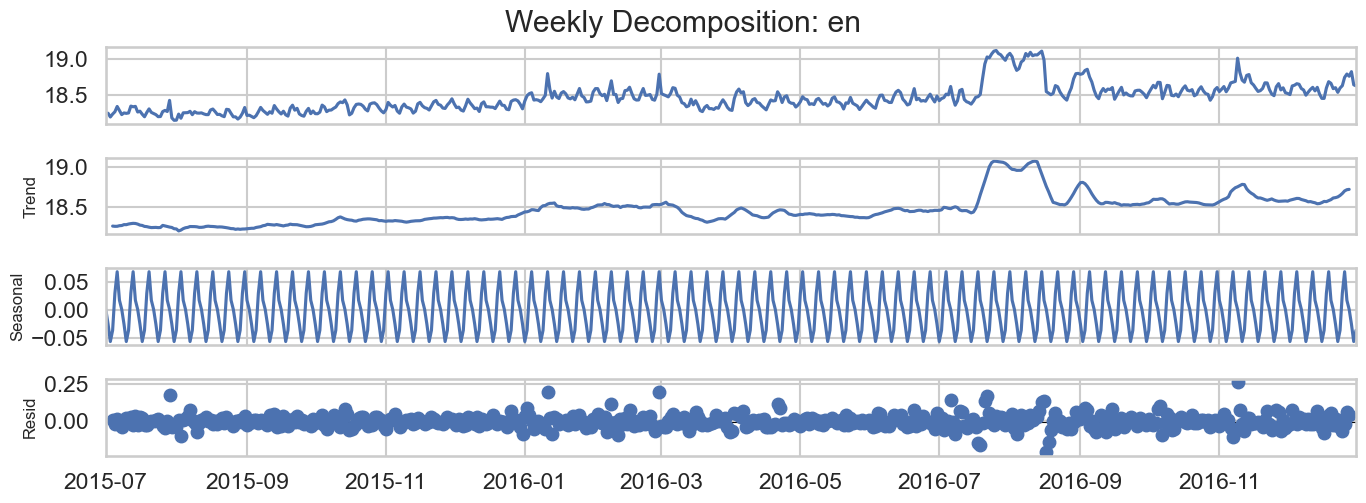

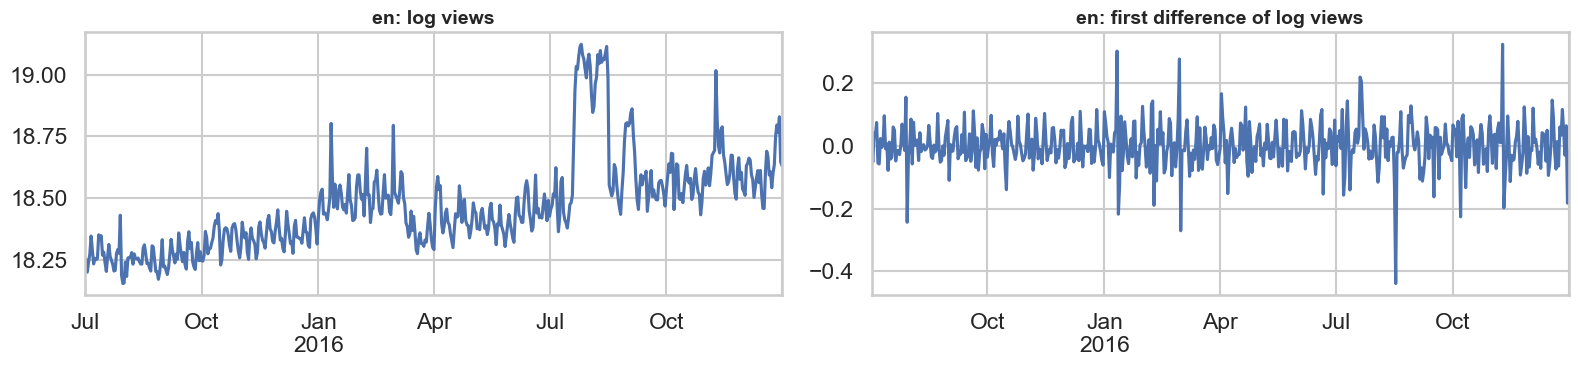

In [86]:
if plt is not None and seasonal_decompose is not None:
    lang = sample_languages[0]
    series = pd.Series(language_ts.loc[lang].values, index = language_ts.columns)
    decomposition = seasonal_decompose(np.log1p(series), model = "additive", period = 7)
    decomposition.plot()
    plt.suptitle(f"Weekly Decomposition: {lang}", y = 1.02)
    plt.show()

    diffed = np.log1p(series).diff().dropna()
    fig, axes = plt.subplots(1,2, figsize = (16,4))
    np.log1p(series).plot(ax = axes[0], title = f"{lang}: log views")
    diffed.plot(ax = axes[1], title = f"{lang}: first difference of log views")
    plt.tight_layout()
    plt.show()

Insights:

The English aggregate page-view series shows a clear upward trend and strong weekly seasonality. The trend gradually increases from July 2015 to early 2016, dips slightly around March-April 2016, and then shows a sharp spike around July-August 2016. This indicates that English page views are affected by both long-term growth and event-driven shocks.

The weekly seasonal component is stable across the full period, suggesting that user behavior follows a recurring day-of-week pattern. Since the decomposition is performed on log views, the seasonal amplitude of about ±0.05 implies weekly deviations of roughly ±5% from the trend.

Residuals are mostly centered around zero, but there are large outliers during high-traffic periods. These outliers suggest the presence of external events, campaigns, or viral topics that cannot be captured by trend and seasonality alone.

After first differencing the log-transformed series, the series becomes more stable around zero. This supports using ARIMA/SARIMAX models with differencing, and also supports adding campaign/event regressors for English pages.

# ACF / PACF Analysis

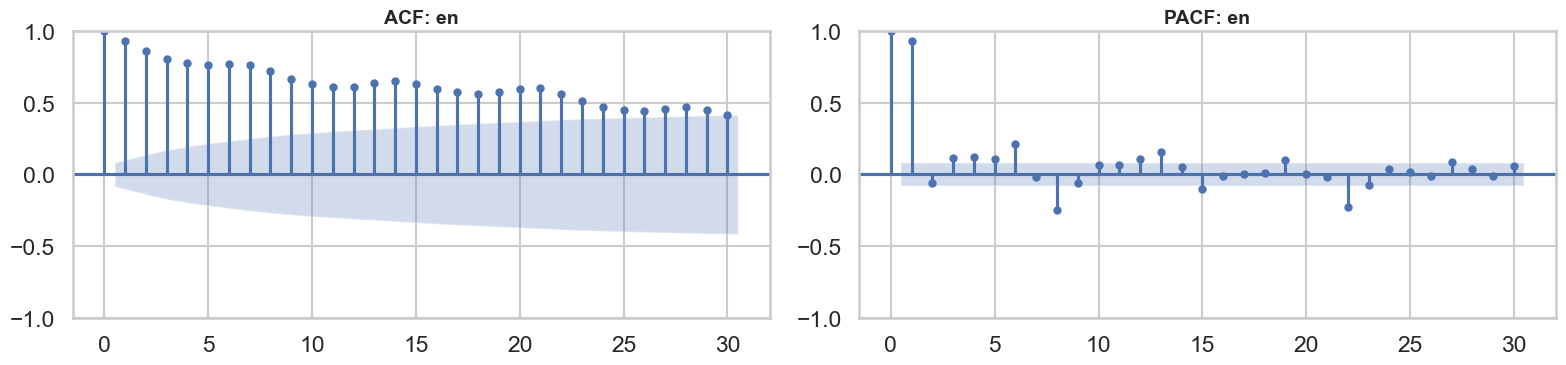

In [88]:
lang = sample_languages[0]
series = np.log1p(pd.Series(language_ts.loc[lang].values, index = language_ts.columns))

fig, axes = plt.subplots(1,2, figsize = (16,4))
plot_acf(series, lags = 30, ax = axes[0])
plot_pacf(series, lags = 30, ax = axes[1], method = "ywm")
axes[0].set_title(f"ACF: {lang}")
axes[1].set_title(f"PACF: {lang}")
plt.tight_layout()
plt.show()

Insights:

The ACF plot for English views shows a slow positive decay across many lags, which indicates strong persistence and non-stationarity. This supports applying first differencing before fitting ARIMA-family models.

The PACF plot shows a dominant spike at lag 1, suggesting that an autoregressive term is important. Smaller recurring spikes around weekly intervals indicate day-of-week effects. Therefore, the English series is better modeled with ARIMA/SARIMAX using first differencing and weekly seasonal terms.

A suitable starting model is ARIMA(1,1,1), while SARIMAX(1,1,1)(1,0,1,7) is more appropriate when weekly seasonality and campaign effects are included.

# ARIMA Modelling

In [97]:
def mape(y_true, y_pred, floor = 1.0):
    y_true = np.asarray(y_true, dtype = float)
    y_pred = np.asarray(y_pred, dtype = float)
    denom = np.maximum(np.abs(y_true), floor)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

In [98]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype = float)
    y_pred = np.asarray(y_pred, dtype = float)
    return np.sqrt(np.mean(y_true - y_pred) ** 2)

In [99]:
TEST_HORIZON = 60
RANDOM_STATE = 42

def train_test_split_series(y, horizon = TEST_HORIZON):
    y = np.asarray(y, dtype = float)
    return y[:-horizon], y[-horizon:]

In [100]:
def grid_search_arima(y_train, p_values=(0,1,2,3,7), d_values = (0,1), q_values = (0,1,2)):
    best = None
    y_train = np.log1p(pd.Series(y_train).astype(float))
    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    model = ARIMA(y_train, order = (p, d, q))
                    fitted = model.fit()
                    candidate = {"order": (p,d,q),
                                 "aic": fitted.aic,
                                 "model": fitted}
                    if best is None or candidate["aic"] < best["aic"]:
                        best = candidate
                except Exception:
                    continue
    return best

In [101]:
def forecast_arima(best_model, horizon):
    log_forecast = best_model["model"].forecast(steps = horizon)
    return np.maximum(np.expm1(log_forecast), 0)

In [102]:
arima_results = []
for lang in language_summary.head(5).index:
    y = language_ts.loc[lang].values
    train, test = train_test_split_series(y)
    best = grid_search_arima(train)
    pred = forecast_arima(best, len(test))
    arima_results.append({
        "language": lang,
        "model": "ARIMA",
        "order": best["order"],
        "aic": best["aic"],
        "mape": mape(test, pred),
        "rmse": rmse(test, pred)
    })
display(pd.DataFrame(arima_results).sort_values("mape"))

,language,model,order,aic,mape,rmse
3,ja,ARIMA,"(7, 0, 2)",-972.32,7.34,"745,308.78"
2,de,ARIMA,"(7, 0, 2)","-1,320.04",7.70,"969,165.60"
4,ru,ARIMA,"(1, 0, 2)",-901.36,8.36,"1,229,277.60"
0,en,ARIMA,"(7, 1, 2)","-1,315.66",9.73,"11,987,233.07"
1,es,ARIMA,"(7, 1, 1)","-1,332.95",12.81,"1,033,895.06"


Insights:

The ARIMA model performs best for Japanese and German, with MAPE values of 7.34% and 7.70%, both below the 8% benchmark. This indicates that these language segments have relatively stable and predictable traffic patterns.

Russian is close to the target with a MAPE of 8.36%, suggesting that ARIMA captures most of the signal but may benefit from seasonal terms.

English and Spanish exceed the benchmark, with MAPE values of 9.73% and 12.81%. English has the largest RMSE because of its much higher traffic volume and event-driven spikes. Spanish shows the weakest ARIMA performance, indicating more relative volatility or less stable autocorrelation.

The selected ARIMA orders often include lag 7 terms, which confirms weekly behavior in page views. Overall, ARIMA is useful as a baseline, but SARIMAX or Prophet should be preferred for languages with strong seasonality, campaigns, or event-driven traffic.

# SARIMAX Modelling with Campaign Regressor

In [ ]:
campaign = exog.iloc[:, 0].astype(float).values
campaign = campaign[:len(dates)]


def fit_sarimax(y_train, exog_train=None, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)):
    y_train = np.log1p(np.asarray(y_train, dtype=float))
    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)


In [104]:
def forecast_sarimax(fitted, horizon, exog_future = None):
    pred_log = fitted.get_forecast(steps = horizon, exog = exog_future).predicted_mean
    return np.maximum(np.expm1(pred_log), 0)

In [105]:
sarimax_results = []
if SARIMAX is not None:
    for lang in language_summary.head(5).index:
        y = language_ts.loc[lang].values
        train, test = train_test_split_series(y)
        if lang == "en":
            exog_train = campaign[:-len(test)].reshape(-1, 1)
            exog_test = campaign[-len(test):].reshape(-1, 1)
        else:
            exog_train = None
            exog_test = None
        fitted = fit_sarimax(train, exog_train=exog_train)
        pred = forecast_sarimax(fitted, len(test), exog_future=exog_test)
        sarimax_results.append({
            "language": lang,
            "model": "SARIMAX",
            "order": (1, 1, 1),
            "seasonal_order": (1, 0, 1, 7),
            "aic": fitted.aic,
            "mape": mape(test, pred),
            "rmse": rmse(test, pred),
        })
    display(pd.DataFrame(sarimax_results).sort_values("mape"))

,language,model,order,seasonal_order,aic,mape,rmse
0,en,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)","-1,536.33",5.86,"6,402,607.58"
3,ja,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)",-981.86,6.21,"590,930.95"
2,de,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)","-1,395.84",6.51,"633,482.62"
4,ru,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)",-887.74,7.63,"1,126,214.15"
1,es,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)","-1,337.31",11.95,"2,147,560.43"


Insights

SARIMAX improves forecasting performance across all evaluated languages compared with ARIMA. The biggest gain is observed for English, where MAPE decreases from 9.73% to 5.86%, comfortably below the 8% benchmark. This indicates that English traffic is strongly influenced by weekly seasonality and benefits from the campaign exogenous variable.

Japanese, German, and Russian also achieve MAPE below 8%, making them reliable markets for forecast-driven ad placement. Spanish remains above the target at 11.95%, suggesting higher volatility or missing explanatory variables.

The selected SARIMAX structure uses first differencing and weekly seasonal terms, confirming that Wikipedia traffic is both persistent and weekly seasonal. Overall, SARIMAX is a stronger candidate than ARIMA for production forecasting, especially for high-value English inventory.

# Facebook Prophet

In [107]:
def make_prophet_frame(y, ds, campaign_values=None):
    out = pd.DataFrame({"ds": pd.to_datetime(ds), "y": np.asarray(y, dtype=float)})
    if campaign_values is not None:
        out["campaign"] = np.asarray(campaign_values, dtype=float)
    return out

In [115]:
def fit_forecast_prophet(y, ds, horizon=TEST_HORIZON, campaign_values=None):
    train_y, test_y = train_test_split_series(y, horizon=horizon)
    train_ds = ds[:-horizon]
    test_ds = ds[-horizon:]
    train_campaign = campaign_values[:-horizon] if campaign_values is not None else None
    test_campaign = campaign_values[-horizon:] if campaign_values is not None else None

    train_df = make_prophet_frame(train_y, train_ds, train_campaign)
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
    )
    if campaign_values is not None:
        model.add_regressor("campaign")
    model.fit(train_df)

    future = pd.DataFrame({"ds": pd.to_datetime(test_ds)})
    if campaign_values is not None:
        future["campaign"] = test_campaign
    forecast = model.predict(future)
    return model, forecast, test_y


prophet_results = []
if Prophet is not None:
    for lang in language_summary.head(5).index:
        y = language_ts.loc[lang].values
        campaign_values = campaign if lang == "en" else None
        model, forecast, test = fit_forecast_prophet(y, language_ts.columns, campaign_values=campaign_values)
        pred = np.maximum(forecast["yhat"].values, 0)
        prophet_results.append({
            "language": lang,
            "model": "Prophet",
            "mape": mape(test, pred),
            "rmse": rmse(test, pred),
        })
    display(pd.DataFrame(prophet_results).sort_values("mape"))

14:41:50 - cmdstanpy - INFO - Chain [1] start processing
14:41:52 - cmdstanpy - INFO - Chain [1] done processing
14:41:52 - cmdstanpy - INFO - Chain [1] start processing
14:41:52 - cmdstanpy - INFO - Chain [1] done processing
14:41:52 - cmdstanpy - INFO - Chain [1] start processing
14:41:52 - cmdstanpy - INFO - Chain [1] done processing
14:41:52 - cmdstanpy - INFO - Chain [1] start processing
14:41:52 - cmdstanpy - INFO - Chain [1] done processing
14:41:52 - cmdstanpy - INFO - Chain [1] start processing
14:41:52 - cmdstanpy - INFO - Chain [1] done processing


,language,model,mape,rmse
3,ja,Prophet,7.32,"366,768.64"
0,en,Prophet,7.79,"7,810,178.57"
2,de,Prophet,7.89,"316,551.53"
1,es,Prophet,12.19,"1,853,783.48"
4,ru,Prophet,38.87,"5,805,550.66"


Insights

Prophet achieves MAPE below the 8% benchmark for Japanese, English, and German, indicating that its trend and seasonality decomposition works reasonably well for these languages. However, Prophet underperforms for Spanish and performs very poorly for Russian, where MAPE rises to 38.87%.

Compared with SARIMAX, Prophet has higher error for every evaluated language. This suggests that the Wikipedia page-view series benefit more from autoregressive and weekly seasonal structure than from Prophet’s default trend-seasonality framework.

Prophet remains useful for interpretability and component-level storytelling, but SARIMAX should be preferred for production forecasting in this case. Russian should be investigated further because Prophet likely failed to capture a level shift, outlier pattern, or holdout-period change.

## Model Comparison Snapshot

The table below summarizes the language-level holdout results already generated in the notebook.

| Language | ARIMA MAPE | SARIMAX MAPE | Prophet MAPE | Recommended Model | Interpretation |
|---|---:|---:|---:|---|---|
| en | 9.73% | **5.86%** | 7.79% | SARIMAX | Highest-value market; campaign-aware SARIMAX brings error well below target. |
| ja | 7.34% | **6.21%** | 7.32% | SARIMAX | Stable and forecastable; suitable for committed inventory planning. |
| de | 7.70% | **6.51%** | 7.89% | SARIMAX | Consistently below benchmark with seasonal modeling. |
| ru | 8.36% | **7.63%** | 38.87% | SARIMAX | SARIMAX handles this segment; Prophet should not be used here without tuning. |
| es | 12.81% | **11.95%** | 12.19% | SARIMAX with more tuning | Still above benchmark; needs segmentation or extra regressors. |

Overall, SARIMAX is the preferred model because it performs best across all five evaluated languages and captures weekly seasonality plus the English campaign effect.


In [116]:
arima_df = pd.DataFrame(arima_results)
sarimax_df = pd.DataFrame(sarimax_results)
prophet_df = pd.DataFrame(prophet_results) if "prophet_results" in globals() else pd.DataFrame()

model_frames = [arima_df, sarimax_df]
if not prophet_df.empty:
    model_frames.append(prophet_df)

model_comparison = pd.concat(model_frames, ignore_index=True, sort=False)
model_comparison = model_comparison.sort_values(["language", "mape"])

display(model_comparison[["language", "model", "mape", "rmse"]].round(2))

mape_matrix = model_comparison.pivot_table(
    index="language",
    columns="model",
    values="mape",
    aggfunc="min",
)

best_model_by_language = (
    model_comparison.sort_values("mape")
    .groupby("language", as_index=False)
    .first()[["language", "model", "mape", "rmse"]]
    .sort_values("mape")
)

display(mape_matrix.round(2))
display(best_model_by_language.round(2))


,language,model,mape,rmse
7,de,SARIMAX,6.51,"633,482.62"
2,de,ARIMA,7.70,"969,165.60"
12,de,Prophet,7.89,"316,551.53"
5,en,SARIMAX,5.86,"6,402,607.58"
10,en,Prophet,7.79,"7,810,178.57"
0,en,ARIMA,9.73,"11,987,233.07"
6,es,SARIMAX,11.95,"2,147,560.43"
11,es,Prophet,12.19,"1,853,783.48"
1,es,ARIMA,12.81,"1,033,895.06"
8,ja,SARIMAX,6.21,"590,930.95"


model,ARIMA,Prophet,SARIMAX
language,,,
de,7.70,7.89,6.51
en,9.73,7.79,5.86
es,12.81,12.19,11.95
ja,7.34,7.32,6.21
ru,8.36,38.87,7.63


,language,model,mape,rmse
1,en,SARIMAX,5.86,"6,402,607.58"
3,ja,SARIMAX,6.21,"590,930.95"
0,de,SARIMAX,6.51,"633,482.62"
4,ru,SARIMAX,7.63,"1,126,214.15"
2,es,SARIMAX,11.95,"2,147,560.43"


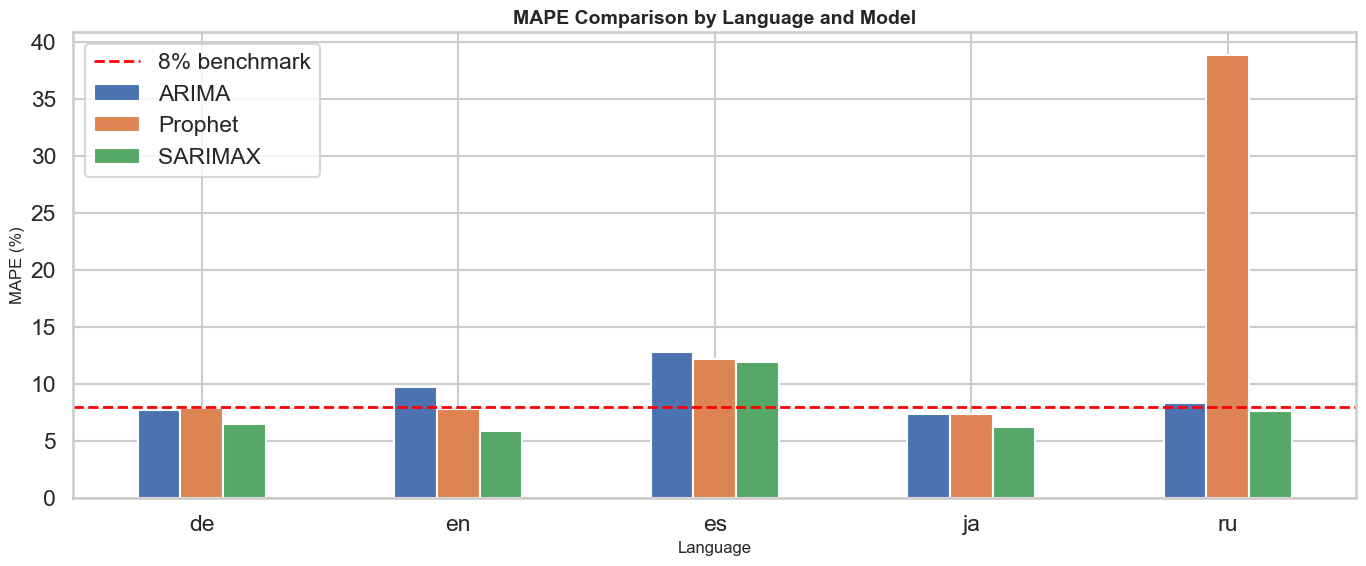

In [117]:
ax = mape_matrix.sort_index().plot(kind="bar", figsize=(14, 6))
ax.axhline(8, color="red", linestyle="--", linewidth=2, label="8% benchmark")
ax.set_title("MAPE Comparison by Language and Model")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("Language")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


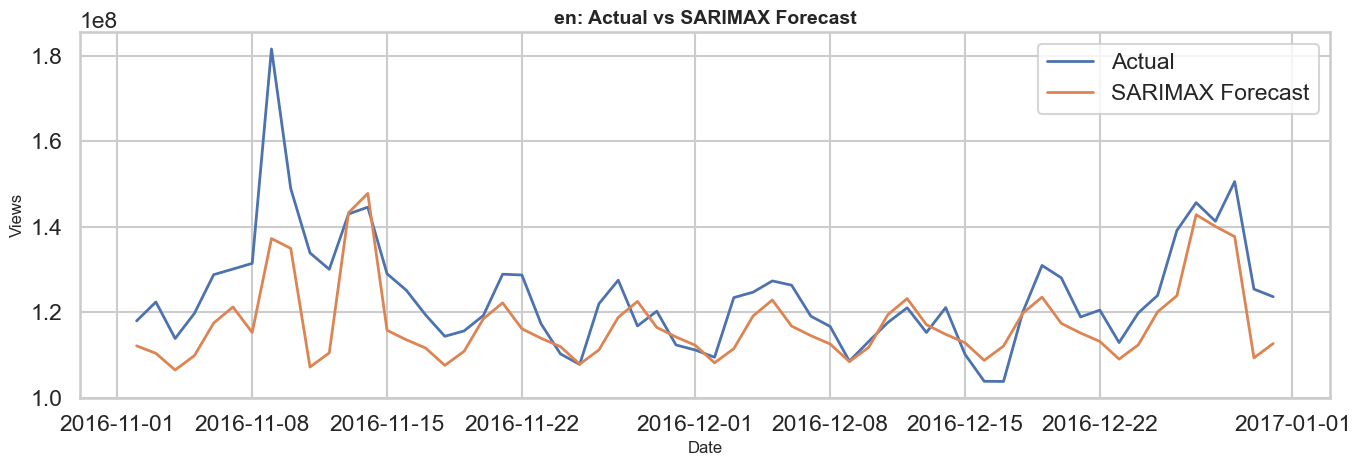

,ds,actual,forecast
0,2016-11-02,"117,972,832.00","112,136,707.51"
1,2016-11-03,"122,391,608.00","110,385,479.65"
2,2016-11-04,"113,847,856.00","106,483,703.61"
3,2016-11-05,"119,729,848.00","109,853,250.87"
4,2016-11-06,"128,780,712.00","117,466,410.76"


In [118]:
def plot_sarimax_holdout(lang="en"):
    y = language_ts.loc[lang].values
    train, test = train_test_split_series(y)

    if lang == "en":
        exog_train = campaign[:-len(test)].reshape(-1, 1)
        exog_test = campaign[-len(test):].reshape(-1, 1)
    else:
        exog_train = None
        exog_test = None

    fitted = fit_sarimax(train, exog_train=exog_train)
    pred = forecast_sarimax(fitted, len(test), exog_future=exog_test)
    test_dates = language_ts.columns[-len(test):]

    plt.figure(figsize=(14, 5))
    plt.plot(test_dates, test, label="Actual", linewidth=2)
    plt.plot(test_dates, pred, label="SARIMAX Forecast", linewidth=2)
    plt.title(f"{lang}: Actual vs SARIMAX Forecast")
    plt.xlabel("Date")
    plt.ylabel("Views")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({"ds": test_dates, "actual": test, "forecast": pred})


en_sarimax_holdout = plot_sarimax_holdout("en")
display(en_sarimax_holdout.head())


## Final Modeling Insights

- **SARIMAX is the best production recommendation.** It gives the strongest overall performance because it captures recent traffic dependence, first differencing, weekly seasonality, and the English campaign regressor.
- **English is the highest-priority ad market.** It has the largest traffic volume and SARIMAX brings its MAPE below the 8% target, making it both commercially important and forecastable.
- **Japanese, German, and Russian are reliable segments.** Their SARIMAX MAPEs are below the benchmark, so they are suitable for forecast-driven inventory planning.
- **Spanish needs additional treatment.** It remains above the benchmark even after SARIMAX/Prophet, suggesting higher volatility, missing events, or a need for page-level segmentation.
- **Prophet is useful for explainability, not the final choice here.** It captures trend and seasonality, but SARIMAX performs better in this experiment.
- **Use MAPE with care for low-volume pages.** Long-tail pages can show high percentage error from small absolute misses; for production, track weighted MAPE or segment-level MAPE in addition to plain MAPE.


# Reusable Multi-Series Forecasting Pipeline

In [119]:
def evaluate_language_pipeline(
    language_ts,
    languages,
    dates,
    campaign=None,
    horizon=60,
    run_prophet=False,
):
    results = []

    for lang in languages:
        y = language_ts.loc[lang].values
        train, test = train_test_split_series(y, horizon=horizon)

        try:
            best_arima = grid_search_arima(train)
            pred_arima = forecast_arima(best_arima, len(test))
            results.append({
                "language": lang,
                "model": "ARIMA",
                "order": best_arima["order"],
                "seasonal_order": None,
                "mape": mape(test, pred_arima),
                "rmse": rmse(test, pred_arima),
            })
        except Exception as err:
            results.append({
                "language": lang,
                "model": "ARIMA",
                "error": str(err),
            })

        try:
            if lang == "en" and campaign is not None:
                exog_train = campaign[:-len(test)].reshape(-1, 1)
                exog_test = campaign[-len(test):].reshape(-1, 1)
            else:
                exog_train = None
                exog_test = None

            fitted_sarimax = fit_sarimax(train, exog_train=exog_train)
            pred_sarimax = forecast_sarimax(fitted_sarimax, len(test), exog_future=exog_test)
            results.append({
                "language": lang,
                "model": "SARIMAX",
                "order": (1, 1, 1),
                "seasonal_order": (1, 0, 1, 7),
                "mape": mape(test, pred_sarimax),
                "rmse": rmse(test, pred_sarimax),
            })
        except Exception as err:
            results.append({
                "language": lang,
                "model": "SARIMAX",
                "error": str(err),
            })

        if run_prophet and PROPHET_OK:
            try:
                campaign_values = campaign if lang == "en" else None
                prophet_model, forecast, test_y = fit_forecast_prophet(
                    y,
                    dates,
                    horizon=horizon,
                    campaign_values=campaign_values,
                )
                pred_prophet = np.maximum(forecast["yhat"].values, 0)
                results.append({
                    "language": lang,
                    "model": "Prophet",
                    "order": None,
                    "seasonal_order": None,
                    "mape": mape(test_y, pred_prophet),
                    "rmse": rmse(test_y, pred_prophet),
                })
            except Exception as err:
                results.append({
                    "language": lang,
                    "model": "Prophet",
                    "error": str(err),
                })

    return pd.DataFrame(results)


# Demonstration on top languages. Set run_prophet=True only if Prophet runtime is available and time permits.
pipeline_demo = evaluate_language_pipeline(
    language_ts=language_ts,
    languages=language_summary.head(5).index.tolist(),
    dates=language_ts.columns,
    campaign=campaign,
    horizon=TEST_HORIZON,
    run_prophet=False,
)

display(pipeline_demo.sort_values(["language", "mape"], na_position="last").round(2))


,language,model,order,seasonal_order,mape,rmse
5,de,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)",6.51,"633,482.62"
4,de,ARIMA,"(7, 0, 2)",None,7.70,"969,165.60"
1,en,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)",5.86,"6,402,607.58"
0,en,ARIMA,"(7, 1, 2)",None,9.73,"11,987,233.07"
3,es,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)",11.95,"2,147,560.43"
2,es,ARIMA,"(7, 1, 1)",None,12.81,"1,033,895.06"
7,ja,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)",6.21,"590,930.95"
6,ja,ARIMA,"(7, 0, 2)",None,7.34,"745,308.78"
9,ru,SARIMAX,"(1, 1, 1)","(1, 0, 1, 7)",7.63,"1,126,214.15"
8,ru,ARIMA,"(1, 0, 2)",None,8.36,"1,229,277.60"


# Business Recommendations

1. **Prioritize English inventory for high-reach campaigns.** English has the highest view volume and becomes accurately forecastable with SARIMAX plus campaign effects.
2. **Offer stable forecast-backed packages for Japanese, German, and Russian pages.** These languages achieve sub-8% SARIMAX MAPE and are suitable for committed impressions/click planning.
3. **Treat Spanish as a flexible-bid segment until improved.** Spanish needs more segmentation or external regressors before AdEase should make strict guaranteed-volume commitments.
4. **Separate human traffic from spider traffic.** Ad placement optimization should focus on browser/human traffic; spider traffic should be excluded from monetizable inventory.
5. **Use weekly pacing.** The data shows strong weekly seasonality, so budgets and bid recommendations should vary by day of week instead of being evenly distributed.
6. **Refresh forecasts around campaigns and events.** Campaign/event spikes can materially change traffic, especially for English pages. Forecasts should be refreshed before and during campaign periods.
7. **Build a two-level forecasting system.** Use language/access-level forecasts for capacity planning and individual page-level forecasts for premium pages where traffic volume justifies extra modeling effort.
